# Step 1 LoRaWAN Network Simulation

Discrete-event simulation of a LoRaWAN network deployed over a 5,377 ha oil palm
plantation in South Kalimantan. Evaluates PDR, collision rate, and weak signal rate
across varying node densities, spreading factors, and traffic loads.

In [ ]:
import numpy as np
import heapq
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product as iterproduct

SEED             = 42
NODES_NUM        = 500
SIM_DURATION     = 86400        # 24 hours
AREA_KM2         = 53.77
AREA_RADIUS_KM   = np.sqrt(AREA_KM2 / np.pi)
TX_INTERVAL_MEAN = 3600         # mean inter-arrival time (s)
WINDOW_S         = 1800         # 30-minute windows for Step 3 aggregation

# AS923 — Indonesian frequency plan
FREQ_MHZ    = 923
CHANNEL_NUM = 8
TX_DBM      = 14
SENS_DBM    = {7: -123.0, 9: -129.0, 12: -137.0}

# Log-distance path loss for oil palm plantation [Anzum et al. 2022]
PL_EXP     = 2.34
PL_D0_KM   = 0.001   # reference distance d0 = 1 m
PL_D0_DB   = 31.5    # path loss at d0 for 923 MHz
SHADOW_STD = 7.0     # shadowing std deviation (dB)

SF = 9               # default spreading factor

print(f"Area        : {AREA_KM2} km2  |  radius {AREA_RADIUS_KM:.2f} km")
print(f"Default SF  : SF{SF}")

Area        : 53.77 km2  |  radius 4.14 km
Default SF  : SF9


## Helper Functions

In [2]:
def time_on_air_s(sf, payload_bytes=30):
    symbol_time = (2**sf) / 125000.0
    de = 1 if sf >= 11 else 0   # low data rate optimisation for SF11/12
    n_symbols = 8 + max(0, (8*payload_bytes - 4*sf + 28 + 16) // (4*(sf - 2*de)) * 5)
    return (8 + 4.25 + n_symbols) * symbol_time


def calculate_path_loss(distance_km, rng):
    d  = max(distance_km, PL_D0_KM)
    pl = PL_D0_DB + 10 * PL_EXP * np.log10(d / PL_D0_KM)
    return pl + rng.normal(0, SHADOW_STD)


def calculate_rssi(distance_km, rng):
    return TX_DBM - calculate_path_loss(distance_km, rng)


for sf in [7, 9, 12]:
    print(f"  ToA SF{sf:2d} = {time_on_air_s(sf)*1000:.1f} ms")

  ToA SF 7 = 66.8 ms
  ToA SF 9 = 205.8 ms
  ToA SF12 = 1482.8 ms


## Simulation Engine

In [3]:
class IoTNode:
    def __init__(self, node_id, x_km, y_km):
        self.node_id = node_id
        self.x = x_km
        self.y = y_km
        self.distance_to_gw = np.sqrt(x_km**2 + y_km**2)

    def __repr__(self):
        return f"Node({self.node_id}, dist={self.distance_to_gw:.2f} km)"


class Event:
    def __init__(self, time, event_type, node):
        self.time = time
        self.event_type = event_type
        self.node = node

    def __lt__(self, other):
        return self.time < other.time


def place_nodes(num_nodes, radius_km, rng):
    nodes = []
    for i in range(num_nodes):
        angle = rng.uniform(0, 2 * np.pi)
        r     = radius_km * np.sqrt(rng.uniform(0, 1))
        nodes.append(IoTNode(i, r * np.cos(angle), r * np.sin(angle)))
    return nodes


def schedule_next_tx(node, current_time, rng, tx_interval):
    return Event(current_time + rng.exponential(tx_interval), 'TRANSMIT', node)


def run_simulation(num_nodes=None, radius_km=None, duration=None,
                   seed=None, sf=None, tx_interval=None):

    if num_nodes   is None: num_nodes   = NODES_NUM
    if radius_km   is None: radius_km   = AREA_RADIUS_KM
    if duration    is None: duration    = SIM_DURATION
    if seed        is None: seed        = SEED
    if sf          is None: sf          = SF
    if tx_interval is None: tx_interval = TX_INTERVAL_MEAN

    tx_dur = time_on_air_s(sf)
    rng    = np.random.default_rng(seed)
    nodes  = place_nodes(num_nodes, radius_km, rng)

    event_queue = []
    for node in nodes:
        t0 = rng.exponential(tx_interval)
        heapq.heappush(event_queue, Event(t0, 'TRANSMIT', node))

    active_tx = {ch: [] for ch in range(CHANNEL_NUM)}
    log = []

    while event_queue:
        event = heapq.heappop(event_queue)
        if event.time > duration:
            break

        node = event.node
        t    = event.time
        ch   = int(rng.integers(0, CHANNEL_NUM))

        active_tx[ch] = [(et, nid) for et, nid in active_tx[ch] if et > t]

        collision = len(active_tx[ch]) > 0
        rssi      = calculate_rssi(node.distance_to_gw, rng)
        signal_ok = rssi >= SENS_DBM[sf]
        success   = (not collision) and signal_ok

        log.append({
            'time'       : t,
            'node_id'    : node.node_id,
            'distance_km': node.distance_to_gw,
            'channel'    : ch,
            'rssi_dbm'   : rssi,
            'collision'  : collision,
            'signal_ok'  : signal_ok,
            'success'    : success,
        })

        active_tx[ch].append((t + tx_dur, node.node_id))

        next_ev = schedule_next_tx(node, t, rng, tx_interval)
        if next_ev.time <= duration:
            heapq.heappush(event_queue, next_ev)

    df    = pd.DataFrame(log)
    total = len(df)
    sc    = df['success'].sum()
    cc    = df['collision'].sum()
    wc    = (~df['signal_ok'] & ~df['collision']).sum()

    return {
        'total_transmissions': total,
        'successful'         : int(sc),
        'pdr'                : sc / total if total > 0 else 0,
        'collision_rate'     : cc / total if total > 0 else 0,
        'weak_signal_rate'   : wc / total if total > 0 else 0,
        'mean_rssi_dbm'      : df['rssi_dbm'].mean(),
    }, df

print("Simulation engine ready.")

Simulation engine ready.


## Baseline Run

SF9 · 500 nodes · 53.77 km2 · TX interval 3,600 s (one packet per hour per node)

In [4]:
results_baseline, df_baseline = run_simulation(sf=9, num_nodes=500)

print(f"  Total transmissions : {results_baseline['total_transmissions']:,}")
print(f"  Successful packets  : {results_baseline['successful']:,}")
print(f"  PDR                 : {results_baseline['pdr']:.2%}")
print(f"  Collision rate      : {results_baseline['collision_rate']:.2%}")
print(f"  Weak signal rate    : {results_baseline['weak_signal_rate']:.2%}")
print(f"  Mean RSSI           : {results_baseline['mean_rssi_dbm']:.1f} dBm")

  Total transmissions : 12,164
  Successful packets  : 12,106
  PDR                 : 99.52%
  Collision rate      : 0.47%
  Weak signal rate    : 0.01%
  Mean RSSI           : -97.3 dBm


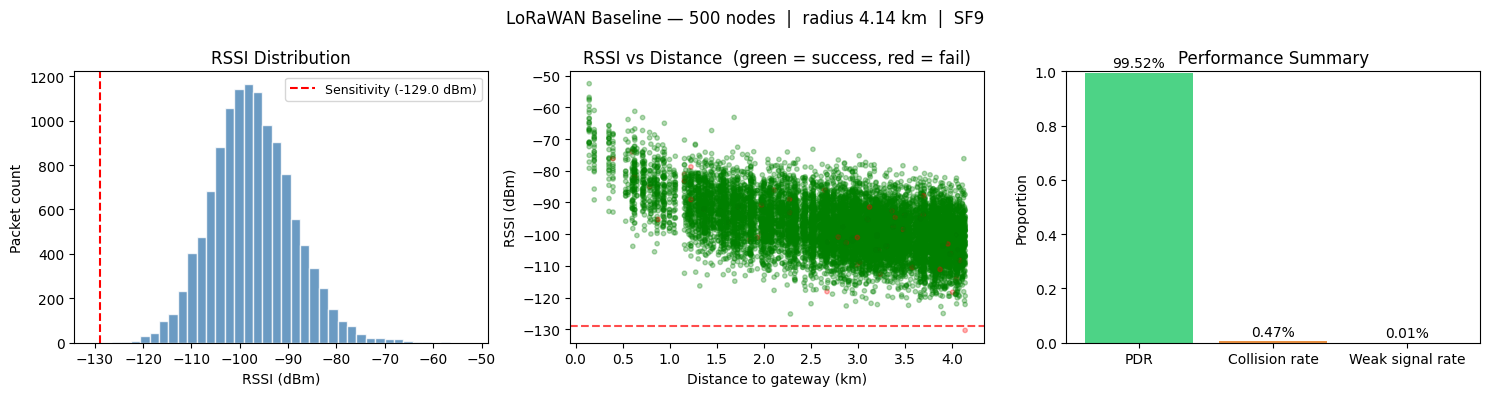

In [5]:
def plot_baseline(df, results, sf=9):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"LoRaWAN Baseline — {df['node_id'].nunique()} nodes  |  "
                 f"radius {AREA_RADIUS_KM:.2f} km  |  SF{sf}", fontsize=12)
    sens = SENS_DBM[sf]

    axes[0].hist(df['rssi_dbm'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0].axvline(sens, color='red', linestyle='--', label=f'Sensitivity ({sens} dBm)')
    axes[0].set_xlabel('RSSI (dBm)')
    axes[0].set_ylabel('Packet count')
    axes[0].set_title('RSSI Distribution')
    axes[0].legend(fontsize=9)

    colors = df['success'].map({True: 'green', False: 'red'})
    axes[1].scatter(df['distance_km'], df['rssi_dbm'], c=colors, alpha=0.3, s=10)
    axes[1].axhline(sens, color='red', linestyle='--', alpha=0.7)
    axes[1].set_xlabel('Distance to gateway (km)')
    axes[1].set_ylabel('RSSI (dBm)')
    axes[1].set_title('RSSI vs Distance  (green = success, red = fail)')

    labels = ['PDR', 'Collision rate', 'Weak signal rate']
    values = [results['pdr'], results['collision_rate'], results['weak_signal_rate']]
    axes[2].bar(labels, values, color=['#2ecc71', '#e67e22', '#e74c3c'], alpha=0.85)
    axes[2].set_ylim(0, 1)
    axes[2].set_ylabel('Proportion')
    axes[2].set_title('Performance Summary')
    for i, v in enumerate(values):
        axes[2].text(i, v + 0.02, f'{v:.2%}', ha='center', fontsize=10)

    plt.tight_layout()
    plt.savefig(f'baseline_SF{sf}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_baseline(df_baseline, results_baseline, sf=9)

## Export Per-Window Data for Step 3

Aggregates simulation results into 30-minute windows across SF7, SF9, and SF12.
The output CSV is read directly by the Step 3 decision system for inference.

In [6]:
SF_LIST_EXPORT = [7, 9, 12]
all_sf_windows = []

for sf_run in SF_LIST_EXPORT:
    _, df_sf = run_simulation(sf=sf_run, num_nodes=NODES_NUM)
    df_sf['window'] = (df_sf['time'] // WINDOW_S).astype(int)
    sf_windows = df_sf.groupby('window').agg(
        pdr_lorawan       =('success',   'mean'),
        collision_rate    =('collision', 'mean'),
        mean_rssi_lorawan =('rssi_dbm',  'mean'),
    ).reset_index()
    sf_windows['spreading_factor'] = sf_run
    all_sf_windows.append(sf_windows)
    print(f"  SF{sf_run:2d}: {len(sf_windows)} windows | "
          f"PDR={sf_windows.pdr_lorawan.mean():.3f} | "
          f"collision={sf_windows.collision_rate.mean():.3f}")

lora_windows = pd.concat(all_sf_windows, ignore_index=True)
lora_windows.to_csv('lorawan_windows.csv', index=False)
print(f"\nSaved lorawan_windows.csv — {len(lora_windows)} rows")
lora_windows.groupby('spreading_factor')[['pdr_lorawan', 'collision_rate']].mean().round(3)

  SF 7: 48 windows | PDR=0.998 | collision=0.001
  SF 9: 48 windows | PDR=0.995 | collision=0.005
  SF12: 48 windows | PDR=0.974 | collision=0.026

Saved lorawan_windows.csv — 144 rows


,pdr_lorawan,collision_rate
spreading_factor,,
7,0.998,0.001
9,0.995,0.005
12,0.974,0.026


## Sweep 1 Node Count x Spreading Factor

Varies node count (100–1,000) and SF (7, 9, 12) with fixed TX interval (3,600 s).

In [7]:
NODE_COUNTS = [100, 200, 300, 500, 750, 1000]
SF_LIST     = [7, 9, 12]

sweep_results = []
for n_nodes, sf in iterproduct(NODE_COUNTS, SF_LIST):
    print(f"  {n_nodes:4d} nodes | SF{sf} ... ", end='')
    res, _ = run_simulation(num_nodes=n_nodes, sf=sf)
    res['num_nodes'] = n_nodes
    res['sf']        = sf
    sweep_results.append(res)
    print(f"PDR {res['pdr']:.2%}  |  collision {res['collision_rate']:.2%}")

sweep_df = pd.DataFrame(sweep_results)
sweep_df.to_csv('lorawan_sweep_nodes_sf.csv', index=False)
print("\nSaved lorawan_sweep_nodes_sf.csv")
sweep_df[['num_nodes', 'sf', 'pdr', 'collision_rate', 'weak_signal_rate', 'mean_rssi_dbm']]

   100 nodes | SF7 ... PDR 99.96%  |  collision 0.00%
   100 nodes | SF9 ... PDR 99.96%  |  collision 0.04%
   100 nodes | SF12 ... PDR 99.60%  |  collision 0.40%
   200 nodes | SF7 ... PDR 99.90%  |  collision 0.04%
   200 nodes | SF9 ... PDR 99.82%  |  collision 0.16%
   200 nodes | SF12 ... PDR 98.71%  |  collision 1.29%
   300 nodes | SF7 ... PDR 99.93%  |  collision 0.03%
   300 nodes | SF9 ... PDR 99.84%  |  collision 0.16%
   300 nodes | SF12 ... PDR 98.52%  |  collision 1.48%
   500 nodes | SF7 ... PDR 99.84%  |  collision 0.13%
   500 nodes | SF9 ... PDR 99.52%  |  collision 0.47%
   500 nodes | SF12 ... PDR 97.37%  |  collision 2.63%
   750 nodes | SF7 ... PDR 99.74%  |  collision 0.21%
   750 nodes | SF9 ... PDR 99.36%  |  collision 0.64%
   750 nodes | SF12 ... PDR 95.97%  |  collision 4.03%
  1000 nodes | SF7 ... PDR 99.73%  |  collision 0.22%
  1000 nodes | SF9 ... PDR 99.26%  |  collision 0.74%
  1000 nodes | SF12 ... PDR 94.75%  |  collision 5.25%

Saved lorawan_sweep_n

,num_nodes,sf,pdr,collision_rate,weak_signal_rate,mean_rssi_dbm
0,100,7,0.999600,0.000000,0.000400,-97.232270
1,100,9,0.999600,0.000400,0.000000,-97.232270
2,100,12,0.996005,0.003995,0.000000,-97.232270
3,200,7,0.998980,0.000408,0.000612,-97.335834
4,200,9,0.998164,0.001632,0.000204,-97.335834
5,200,12,0.987148,0.012852,0.000000,-97.335834
6,300,7,0.999313,0.000275,0.000412,-97.493732
7,300,9,0.998352,0.001648,0.000000,-97.493732
8,300,12,0.985171,0.014829,0.000000,-97.493732
9,500,7,0.998438,0.001315,0.000247,-97.305945


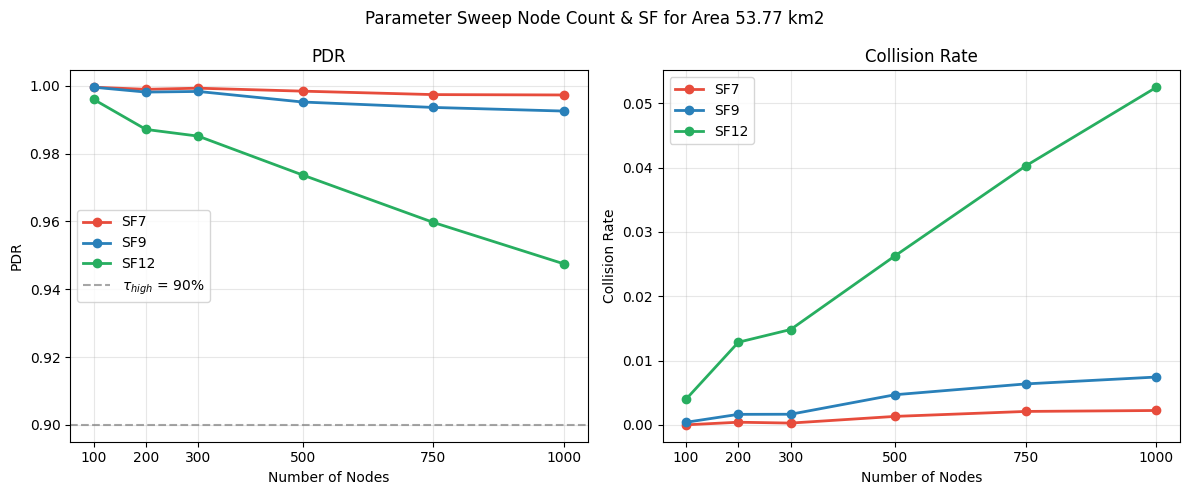

: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Parameter Sweep Node Count & SF for Area 53.77 km2", fontsize=12)

colors_sf = {7: '#e74c3c', 9: '#2980b9', 12: '#27ae60'}
metrics   = [
    ('pdr',              'PDR'),
    ('collision_rate',   'Collision Rate'),
    ('weak_signal_rate', 'Weak Signal Rate'),
]

for ax, (col, ylabel) in zip(axes, metrics):
    for sf in SF_LIST:
        sub = sweep_df[sweep_df['sf'] == sf]
        ax.plot(sub['num_nodes'], sub[col], marker='o',
                label=f'SF{sf}', color=colors_sf[sf], linewidth=2)
    if col == 'pdr':
        ax.axhline(0.90, color='gray', linestyle='--', alpha=0.7, label=r'$\tau_{high}$ = 90%')
    ax.set_xlabel('Number of Nodes')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(NODE_COUNTS)

plt.tight_layout()
plt.savefig('sweep1_nodes_sf.png', dpi=150, bbox_inches='tight')
plt.show()

## Sweep 2 TX Interval (Traffic Load)

Fixed node count (500) and SF9. Higher traffic load means more collisions,
even with the same number of nodes.

In [9]:
TX_INTERVAL_LIST = [3600, 1800, 900, 300]
SF_FIXED         = 9
NODES_FIXED      = 500

tx_sweep_results = []
for tx_int in TX_INTERVAL_LIST:
    label = f"{tx_int // 60} min"
    print(f"  TX interval {tx_int:4d} s ({label:>6s}) ... ", end='')
    res, _ = run_simulation(num_nodes=NODES_FIXED, sf=SF_FIXED, tx_interval=tx_int)
    res['tx_interval'] = tx_int
    res['tx_label']    = label
    tx_sweep_results.append(res)
    print(f"PDR {res['pdr']:.2%}  |  collision {res['collision_rate']:.2%}")

tx_sweep_df = pd.DataFrame(tx_sweep_results)
tx_sweep_df.to_csv('lorawan_sweep_tx_interval.csv', index=False)
print("\nSaved lorawan_sweep_tx_interval.csv")
tx_sweep_df[['tx_interval', 'tx_label', 'pdr', 'collision_rate', 'weak_signal_rate', 'mean_rssi_dbm']]

  TX interval 3600 s (60 min) ... PDR 99.52%  |  collision 0.47%
  TX interval 1800 s (30 min) ... PDR 99.21%  |  collision 0.78%
  TX interval  900 s (15 min) ... PDR 98.50%  |  collision 1.50%
  TX interval  300 s ( 5 min) ... PDR 95.75%  |  collision 4.25%

Saved lorawan_sweep_tx_interval.csv


,tx_interval,tx_label,pdr,collision_rate,weak_signal_rate,mean_rssi_dbm
0,3600,60 min,0.995232,0.004686,0.000082,-97.305945
1,1800,30 min,0.992114,0.007845,0.000041,-97.236360
2,900,15 min,0.984990,0.014990,0.000021,-97.253363
3,300,5 min,0.957533,0.042454,0.000014,-97.257051


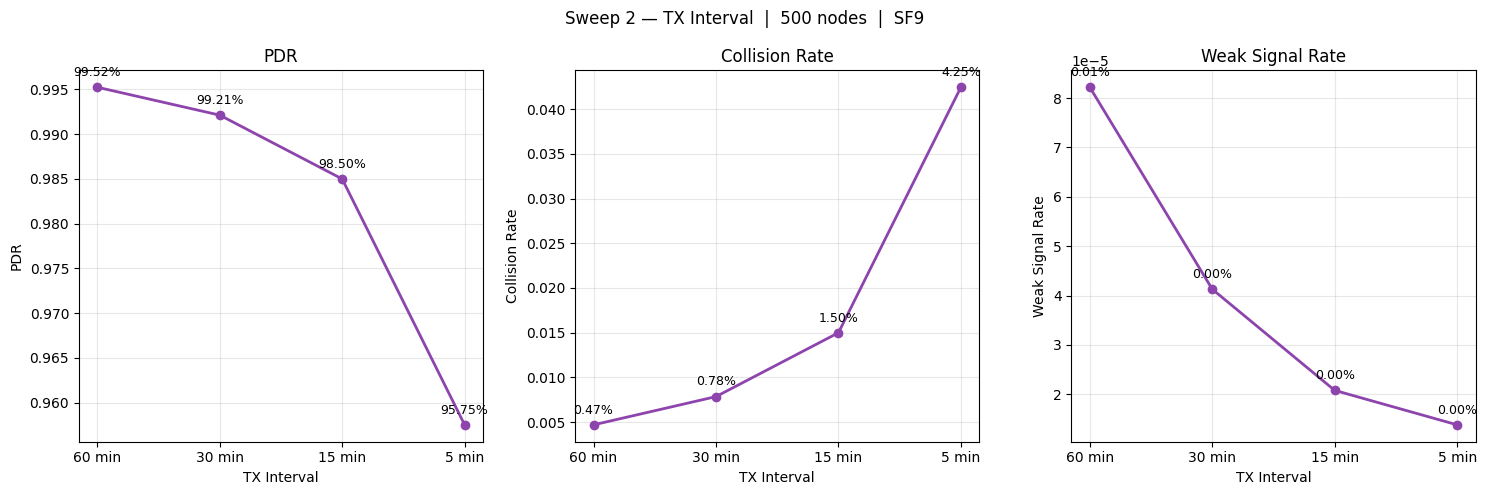

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Sweep 2 — TX Interval  |  {NODES_FIXED} nodes  |  SF{SF_FIXED}", fontsize=12)

metrics  = [('pdr', 'PDR'), ('collision_rate', 'Collision Rate'), ('weak_signal_rate', 'Weak Signal Rate')]
x_labels = tx_sweep_df['tx_label'].tolist()

for ax, (col, ylabel) in zip(axes, metrics):
    ax.plot(x_labels, tx_sweep_df[col], marker='o', color='#8e44ad', linewidth=2)
    ax.set_xlabel('TX Interval')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.grid(True, alpha=0.3)
    for x, y in zip(x_labels, tx_sweep_df[col]):
        ax.annotate(f'{y:.2%}', (x, y), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('sweep2_tx_interval.png', dpi=150, bbox_inches='tight')
plt.show()

## Node Map Visualisation

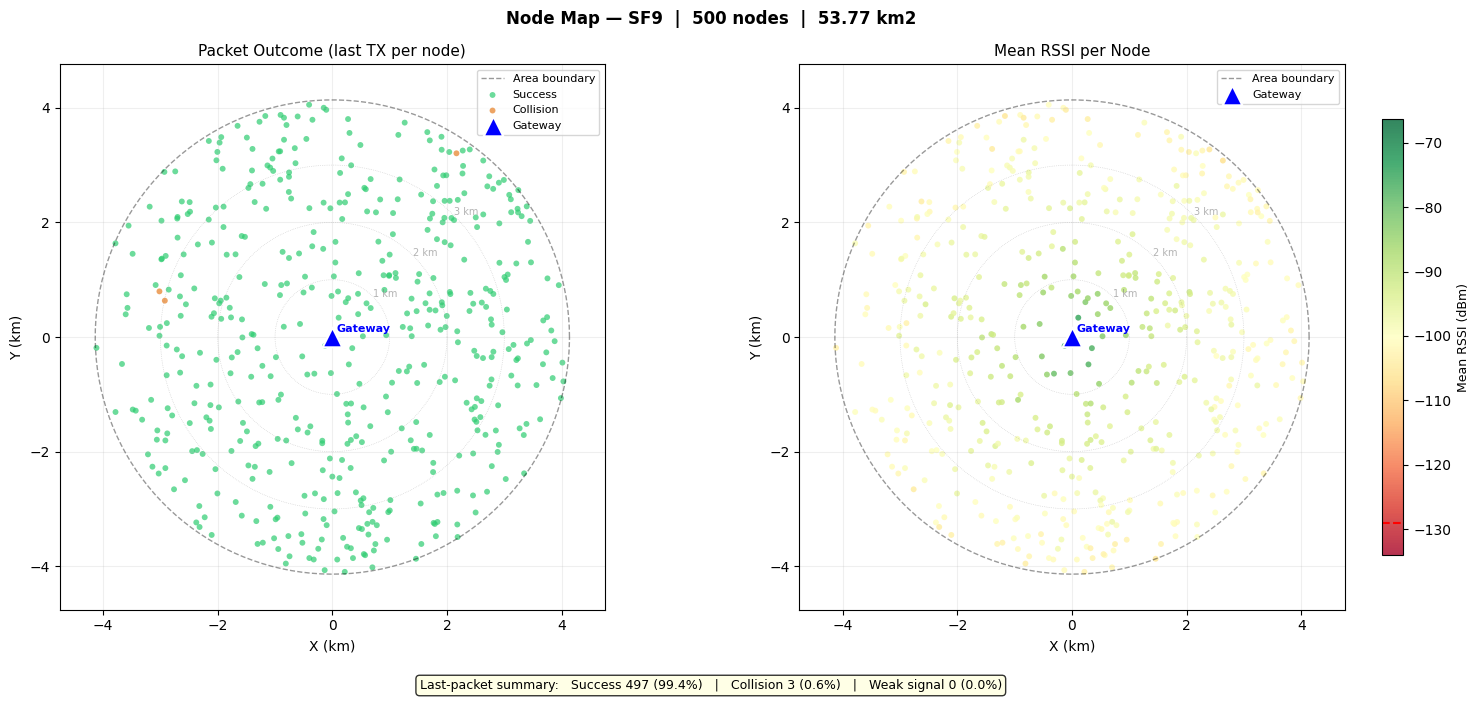

In [11]:
def plot_node_map(df, num_nodes=500, sf=9, radius_km=None, seed=None):
    if radius_km is None: radius_km = AREA_RADIUS_KM
    if seed      is None: seed      = SEED

    rng      = np.random.default_rng(seed)
    nodes    = place_nodes(num_nodes, radius_km, rng)
    node_pos = {n.node_id: (n.x, n.y) for n in nodes}

    last_status = (
        df.sort_values('time')
          .groupby('node_id').last()
          .reset_index()[['node_id', 'success', 'collision', 'signal_ok']]
    )

    def get_status(row):
        if row['success']:   return 'success'
        if row['collision']: return 'collision'
        return 'weak_signal'

    last_status['status'] = last_status.apply(get_status, axis=1)
    color_map = {'success': '#2ecc71', 'collision': '#e67e22', 'weak_signal': '#e74c3c'}
    label_map = {'success': 'Success', 'collision': 'Collision', 'weak_signal': 'Weak signal'}

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f"Node Map — SF{sf}  |  {num_nodes} nodes  |  {AREA_KM2} km2",
                 fontsize=12, fontweight='bold')

    theta = np.linspace(0, 2 * np.pi, 300)

    for ax, show_rssi in zip(axes, [False, True]):
        ax.plot(radius_km * np.cos(theta), radius_km * np.sin(theta),
                'k--', linewidth=1, alpha=0.4, label='Area boundary')
        for r_ref in [1, 2, 3]:
            if r_ref < radius_km:
                ax.plot(r_ref * np.cos(theta), r_ref * np.sin(theta),
                        color='gray', linewidth=0.5, linestyle=':', alpha=0.4)
                ax.text(r_ref * 0.707, r_ref * 0.707, f'{r_ref} km',
                        fontsize=7, color='gray', alpha=0.6)

        if not show_rssi:
            plotted = set()
            for _, row in last_status.iterrows():
                nid = row['node_id']
                if nid not in node_pos: continue
                x, y   = node_pos[nid]
                status = row['status']
                lbl    = label_map[status] if status not in plotted else None
                ax.scatter(x, y, c=color_map[status], s=18, alpha=0.7,
                           edgecolors='none', label=lbl)
                plotted.add(status)
            ax.set_title('Packet Outcome (last TX per node)', fontsize=11)
        else:
            rssi_mean = df.groupby('node_id')['rssi_dbm'].mean()
            xs   = [node_pos[n][0] for n in rssi_mean.index if n in node_pos]
            ys   = [node_pos[n][1] for n in rssi_mean.index if n in node_pos]
            vals = [rssi_mean[n]   for n in rssi_mean.index if n in node_pos]
            sc   = ax.scatter(xs, ys, c=vals, cmap='RdYlGn', s=18, alpha=0.8,
                              edgecolors='none', vmin=SENS_DBM[sf] - 5, vmax=max(vals))
            cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
            cbar.set_label('Mean RSSI (dBm)', fontsize=9)
            cbar.ax.axhline(SENS_DBM[sf], color='red', linewidth=1.5, linestyle='--')
            ax.set_title('Mean RSSI per Node', fontsize=11)

        ax.scatter(0, 0, c='blue', s=200, marker='^', zorder=5,
                   label='Gateway', edgecolors='white', linewidth=1.5)
        ax.text(0.08, 0.08, 'Gateway', fontsize=8, color='blue', fontweight='bold')
        ax.set_xlabel('X (km)')
        ax.set_ylabel('Y (km)')
        ax.set_aspect('equal')
        ax.set_xlim(-radius_km * 1.15, radius_km * 1.15)
        ax.set_ylim(-radius_km * 1.15, radius_km * 1.15)
        ax.grid(True, alpha=0.2)
        ax.legend(loc='upper right', fontsize=8, framealpha=0.8)

    total = len(last_status)
    n_s   = (last_status['status'] == 'success').sum()
    n_c   = (last_status['status'] == 'collision').sum()
    n_w   = (last_status['status'] == 'weak_signal').sum()
    fig.text(0.5, 0.01,
             f"Last-packet summary:   Success {n_s} ({n_s/total:.1%})   |   "
             f"Collision {n_c} ({n_c/total:.1%})   |   Weak signal {n_w} ({n_w/total:.1%})",
             ha='center', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig(f'node_map_SF{sf}_N{num_nodes}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_node_map(df_baseline, num_nodes=500, sf=9)

## Node History

In [12]:
node_id = 42   # change to inspect a different node

node_history = df_baseline[df_baseline['node_id'] == node_id].copy()
node_history['time_hhmm'] = pd.to_datetime(node_history['time'], unit='s').dt.strftime('%H:%M:%S')

print(f"Node {node_id} — total transmissions: {len(node_history)}")
print(node_history[['time_hhmm', 'channel', 'rssi_dbm', 'collision', 'success']].to_string())

Node 42 — total transmissions: 24
      time_hhmm  channel    rssi_dbm  collision  success
25     00:04:05        2  -99.444956      False     True
1034   02:03:03        2  -89.240012      False     True
1367   02:41:21        7  -90.078395      False     True
1802   03:28:36        6 -101.192090      False     True
2198   04:12:30        0  -81.406767      False     True
2280   04:20:13        6  -98.685858      False     True
2658   05:08:03        7  -80.888184      False     True
2849   05:31:12        5  -97.167985      False     True
3812   07:24:45        2 -100.779990      False     True
3978   07:45:17        7  -87.013257      False     True
4173   08:09:14        2  -86.941252      False     True
6239   12:17:57        2  -75.436620      False     True
6638   13:03:27        5  -93.238139      False     True
6654   13:05:41        2  -85.409897      False     True
7796   15:22:13        4  -94.751845      False     True
7979   15:43:38        4  -92.324764      False     Tr

## Heatmap Sweep : Node Count x TX Interval

SF9 fixed. Shows how PDR and collision rate change across combinations of
node density and traffic load.

In [13]:
HEATMAP_NODES  = [200, 500, 750, 1000]
HEATMAP_TX_INT = [3600, 1800, 900, 300]
TX_LABELS      = ['60 min', '30 min', '15 min', '5 min']
SF_FIXED_HM    = 9

print("Running heatmap sweep (SF9)...")
pdr_matrix       = np.zeros((len(HEATMAP_NODES), len(HEATMAP_TX_INT)))
collision_matrix = np.zeros_like(pdr_matrix)

for i, n_nodes in enumerate(HEATMAP_NODES):
    for j, tx_int in enumerate(HEATMAP_TX_INT):
        print(f"  {n_nodes:4d} nodes | TX {tx_int:4d} s ... ", end='')
        res, _ = run_simulation(num_nodes=n_nodes, sf=SF_FIXED_HM, tx_interval=tx_int)
        pdr_matrix[i, j]       = res['pdr']
        collision_matrix[i, j] = res['collision_rate']
        print(f"PDR {res['pdr']:.2%}  |  collision {res['collision_rate']:.2%}")

print("Done.")

Running heatmap sweep (SF9)...
   200 nodes | TX 3600 s ... PDR 99.82%  |  collision 0.16%
   200 nodes | TX 1800 s ... PDR 99.66%  |  collision 0.33%
   200 nodes | TX  900 s ... PDR 99.43%  |  collision 0.56%
   200 nodes | TX  300 s ... PDR 98.28%  |  collision 1.71%
   500 nodes | TX 3600 s ... PDR 99.52%  |  collision 0.47%
   500 nodes | TX 1800 s ... PDR 99.21%  |  collision 0.78%
   500 nodes | TX  900 s ... PDR 98.50%  |  collision 1.50%
   500 nodes | TX  300 s ... PDR 95.75%  |  collision 4.25%
   750 nodes | TX 3600 s ... PDR 99.36%  |  collision 0.64%
   750 nodes | TX 1800 s ... PDR 98.86%  |  collision 1.14%
   750 nodes | TX  900 s ... PDR 97.79%  |  collision 2.20%
   750 nodes | TX  300 s ... PDR 93.69%  |  collision 6.31%
  1000 nodes | TX 3600 s ... PDR 99.26%  |  collision 0.74%
  1000 nodes | TX 1800 s ... PDR 98.56%  |  collision 1.44%
  1000 nodes | TX  900 s ... PDR 97.09%  |  collision 2.91%
  1000 nodes | TX  300 s ... PDR 91.73%  |  collision 8.27%
Done.


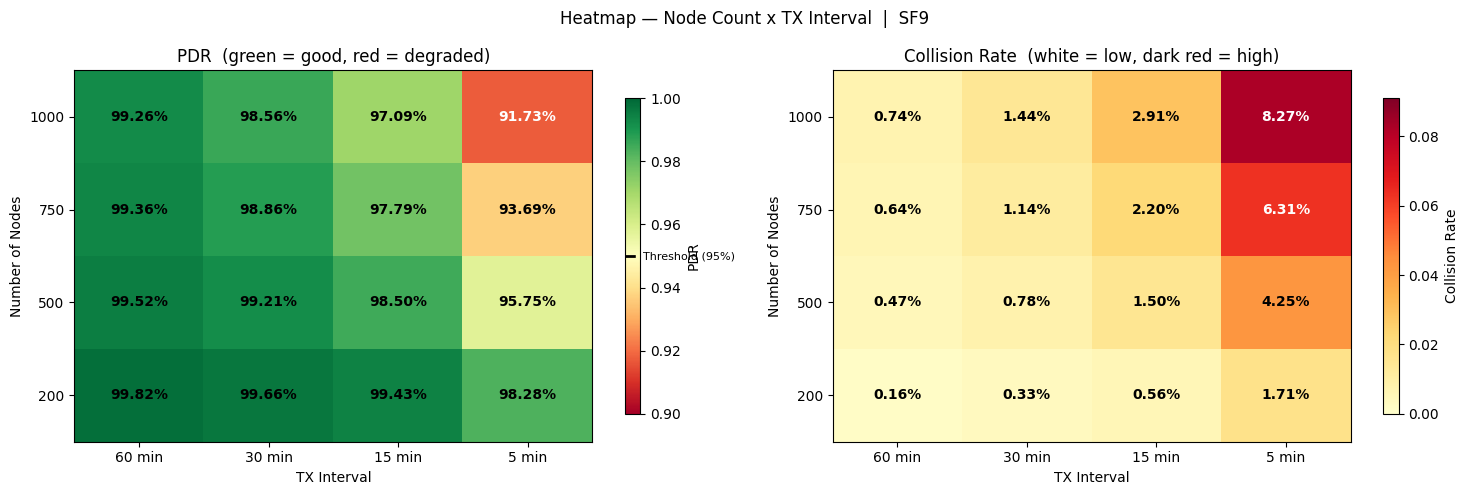

Saved lorawan_sweep_heatmap.csv


In [14]:
fig, axes   = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f"Heatmap — Node Count x TX Interval  |  SF{SF_FIXED_HM}", fontsize=12)

node_labels = [str(n) for n in HEATMAP_NODES]
THRESHOLD   = 0.95
hmap_kw     = dict(aspect='auto', origin='lower')

im0 = axes[0].imshow(pdr_matrix, cmap='RdYlGn', vmin=0.90, vmax=1.0, **hmap_kw)
axes[0].set_xticks(range(len(TX_LABELS)));     axes[0].set_xticklabels(TX_LABELS)
axes[0].set_yticks(range(len(HEATMAP_NODES))); axes[0].set_yticklabels(node_labels)
axes[0].set_xlabel('TX Interval')
axes[0].set_ylabel('Number of Nodes')
axes[0].set_title('PDR  (green = good, red = degraded)')
cbar0 = plt.colorbar(im0, ax=axes[0], shrink=0.85)
cbar0.set_label('PDR')
cbar0.ax.axhline(THRESHOLD, color='black', linewidth=2, linestyle='--')
cbar0.ax.text(1.15, THRESHOLD, f'Threshold ({THRESHOLD:.0%})',
              transform=cbar0.ax.get_yaxis_transform(), fontsize=8, va='center')
for i in range(len(HEATMAP_NODES)):
    for j in range(len(HEATMAP_TX_INT)):
        val = pdr_matrix[i, j]
        axes[0].text(j, i, f'{val:.2%}', ha='center', va='center',
                     fontsize=10, color='white' if val < 0.93 else 'black', fontweight='bold')

im1 = axes[1].imshow(collision_matrix, cmap='YlOrRd',
                      vmin=0, vmax=collision_matrix.max() * 1.1, **hmap_kw)
axes[1].set_xticks(range(len(TX_LABELS)));     axes[1].set_xticklabels(TX_LABELS)
axes[1].set_yticks(range(len(HEATMAP_NODES))); axes[1].set_yticklabels(node_labels)
axes[1].set_xlabel('TX Interval')
axes[1].set_ylabel('Number of Nodes')
axes[1].set_title('Collision Rate  (white = low, dark red = high)')
cbar1 = plt.colorbar(im1, ax=axes[1], shrink=0.85)
cbar1.set_label('Collision Rate')
for i in range(len(HEATMAP_NODES)):
    for j in range(len(HEATMAP_TX_INT)):
        val = collision_matrix[i, j]
        axes[1].text(j, i, f'{val:.2%}', ha='center', va='center', fontsize=10,
                     color='white' if val > collision_matrix.max() * 0.6 else 'black',
                     fontweight='bold')

plt.tight_layout()
plt.savefig('heatmap_nodes_tx.png', dpi=150, bbox_inches='tight')
plt.show()

hm_rows = []
for i, n in enumerate(HEATMAP_NODES):
    for j, tx in enumerate(HEATMAP_TX_INT):
        hm_rows.append({'num_nodes': n, 'tx_interval_s': tx, 'tx_label': TX_LABELS[j],
                         'pdr': pdr_matrix[i, j], 'collision_rate': collision_matrix[i, j]})
pd.DataFrame(hm_rows).to_csv('lorawan_sweep_heatmap.csv', index=False)
print("Saved lorawan_sweep_heatmap.csv")